### Script Description: Vanilla SAM applied on confocal images
#### Input data: /content/drive/MyDrive/SAMPLS/input_images_and_segmentation_results/
#### Output: mask pickle files

In [27]:
import numpy as np
from numpy import array
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageStat
from skimage import io, util, color
from scipy.optimize import linear_sum_assignment
import sys
import cv2
import pickle
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

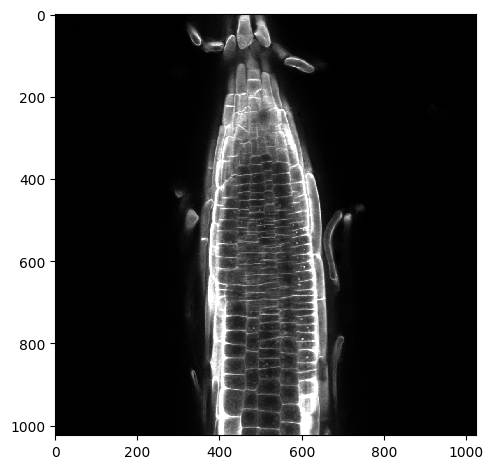

In [28]:
image = io.imread("/projects/intro2gds/Chirag_2024/SAMPLS/input_images_and_segmentation_results/image_3/input_img_3.tif")
io.imshow(image)

#### upload pre-trained SAM weights

In [29]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

HOME: /projects/intro2gds/Chirag_2024/notebooks/weights


In [30]:
%cd {HOME}

import sys
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

/projects/intro2gds/Chirag_2024/notebooks/weights


  Cloning https://github.com/facebookresearch/segment-anything.git to /localscratch/2713022/pip-req-build-hhl62tc8
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /localscratch/2713022/pip-req-build-hhl62tc8
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [31]:
%pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision

Note: you may need to restart the kernel to use updated packages.


In [32]:
%cd {HOME}
!mkdir {HOME}/weights
%cd {HOME}/weights

!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

/projects/intro2gds/Chirag_2024/notebooks/weights


/projects/intro2gds/Chirag_2024/notebooks/weights/weights


In [33]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/projects/intro2gds/Chirag_2024/notebooks/weights/weights/sam_vit_h_4b8939.pth ; exist: True


In [34]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [52]:
import torch

# Check if CUDA is available and set the device
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

# Print whether CUDA is available or not
if torch.cuda.is_available():
    print(f"CUDA is available. Using {DEVICE}.")
else:
    print(f"CUDA is not available. Using {DEVICE}.")


CUDA is available. Using cuda:0.


In [35]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

In [36]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [37]:
import supervision as sv
sam_result = mask_generator.generate(image)

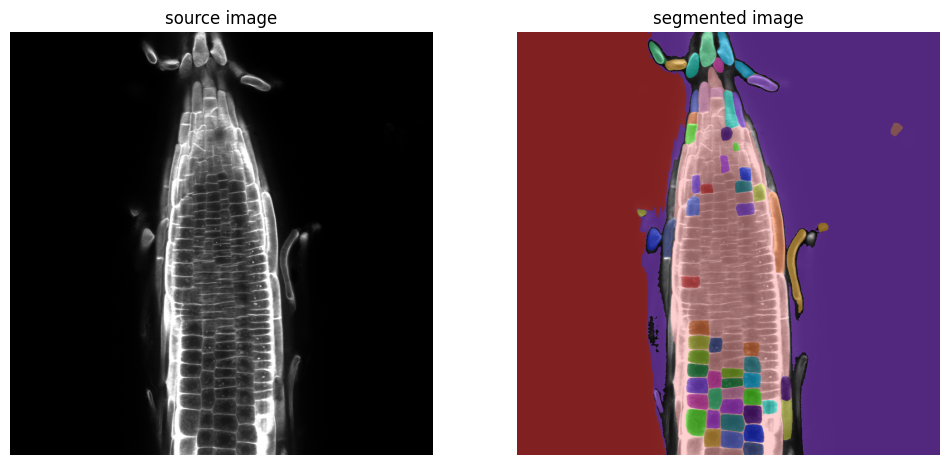

In [38]:
mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated2_image = mask_annotator.annotate(scene=image.copy(), detections=detections)

sv.plot_images_grid(
    images=[image, annotated2_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image'])

In [39]:
io.imsave('/projects/intro2gds/Chirag_2024/weights/annotated2_image.jpg', annotated2_image)

In [40]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

In [41]:
# Mask Selection Tool

# Initialize variables
selected_masks = [False] * len(masks)

# Create a grid layout to display masks and checkboxes
grid_layout = widgets.GridspecLayout(len(masks), 3, width='60%')
mask_widgets = []

# Function to toggle mask selection
def toggle_selection(change, index):
    selected_masks[index] = not selected_masks[index]

# Function to display masks and checkboxes
def display_masks():
    for i, mask in enumerate(masks):
        checkbox = widgets.Checkbox(value=False, description='Include')
        checkbox.observe(lambda change, index=i: toggle_selection(change, index), names='value')

        mask_widgets.append(widgets.Image(value=image_to_byte_array(mask), format="png"))
        mask_widgets[-1].layout.height = '200px'

        grid_layout[i, 0] = checkbox
        grid_layout[i, 1] = mask_widgets[-1]

# Convert NumPy array to byte array for display
def image_to_byte_array(image):
    from io import BytesIO
    img_byte_array = BytesIO()
    plt.imsave(img_byte_array, image, format='png')
    return img_byte_array.getvalue()

# Display the masks and checkboxes
display_masks()

# Create a button to apply the selection
apply_button = widgets.Button(description="Apply Selection")
output = widgets.Output()

# Function to apply the selection and create new lists
def apply_selection(_):
    global selected_masks
    global unselected_masks

    # Create new lists for selected and unselected masks
    selected_mask_list = [mask for mask, selected in zip(masks, selected_masks) if not selected]
    unselected_mask_list = [mask for mask, selected in zip(masks, selected_masks) if selected]

    # Update mask_list and selected_masks
    selected_masks = selected_mask_list
    # unselected_masks = [False] * len(masks)
    unselected_masks = unselected_mask_list

    with output:
        print("Selected images discarded.")
        print("Unselected images included.")


# Bind button action
apply_button.on_click(apply_selection)


# Display the checkboxes, images, and the Apply button
display(widgets.VBox([grid_layout, apply_button, output]))


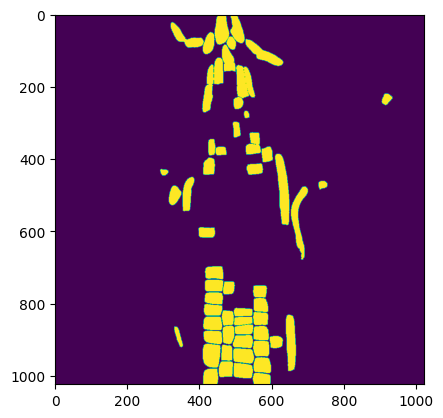

In [42]:
import numpy as np

# Assuming you have a list of object masks (masks) and an image size (image_height, image_width)

# Initialize an empty mask with the same dimensions as your image
empty_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Iterate through the 10 individual object masks and combine them
for object_mask in selected_masks:
    empty_mask = np.logical_or(empty_mask, object_mask)

plt.imshow(empty_mask)

In [43]:
mask_predictor = SamPredictor(sam)

In [44]:
# helper function that loads an image before adding it to the widget

import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

In [45]:
# from ipywidgets import widgets
# IS_COLAB = True

# if IS_COLAB:
#     from google.colab import output
#     output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget # Adjust the figure size as needed

# plt.imshow(annotated2_image, cmap='gray')  # Replace 'gray' with the appropriate colormap

widget = BBoxWidget()
widget.image = encode_image("/projects/intro2gds/Chirag_2024/weights/annotated2_image.jpg")
# widget.image = encode_image("/content/drive/MyDrive/consolidated_images/6.png")
widget

BBoxWidget(colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#b…

In [46]:
# initialize an empty list to store prompted masks
prompt_masks = []

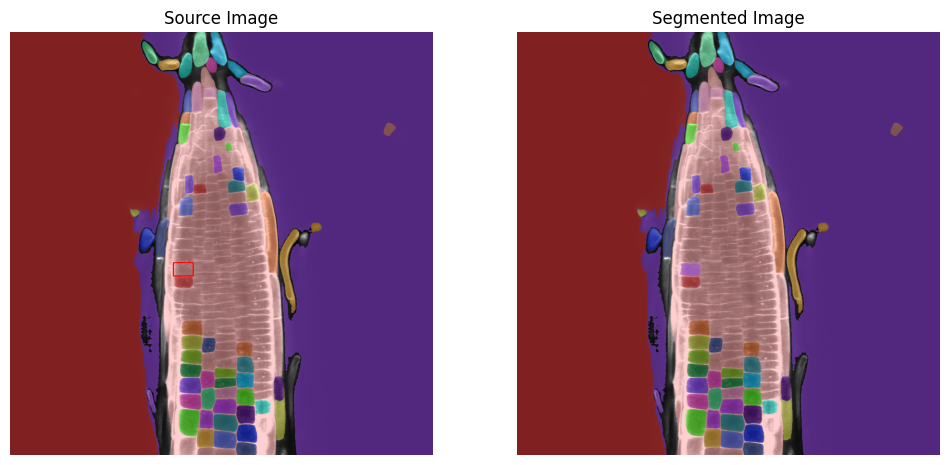

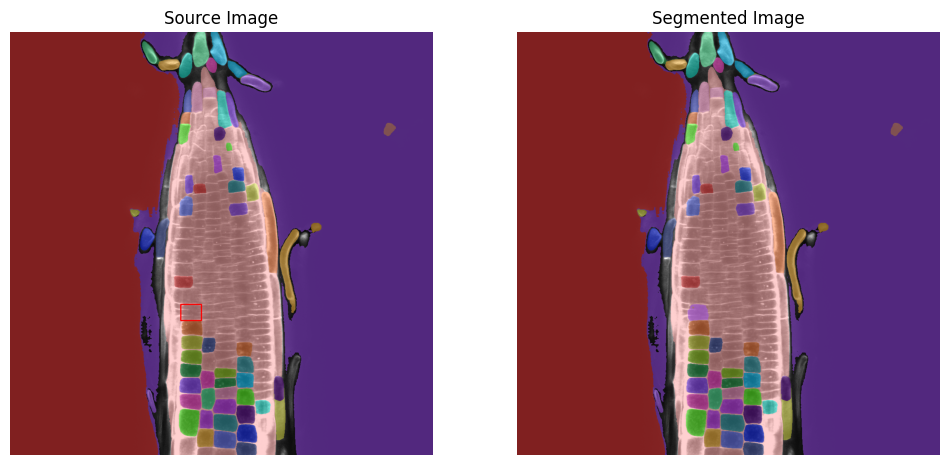

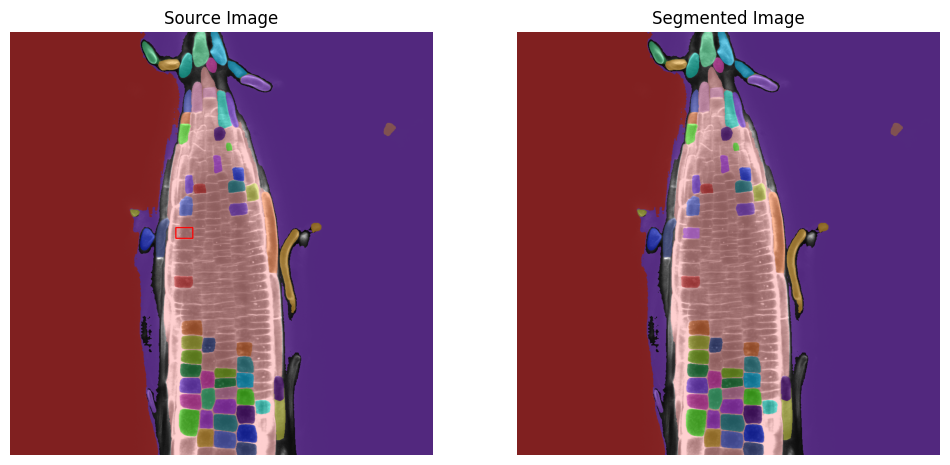

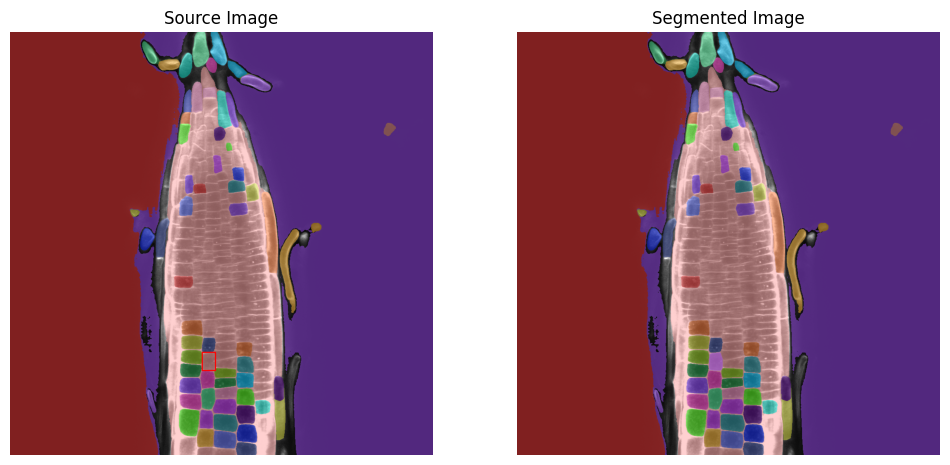

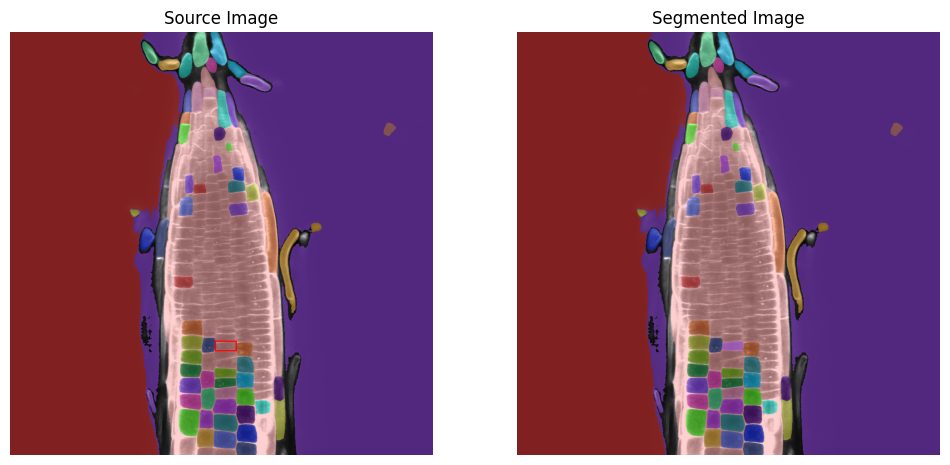

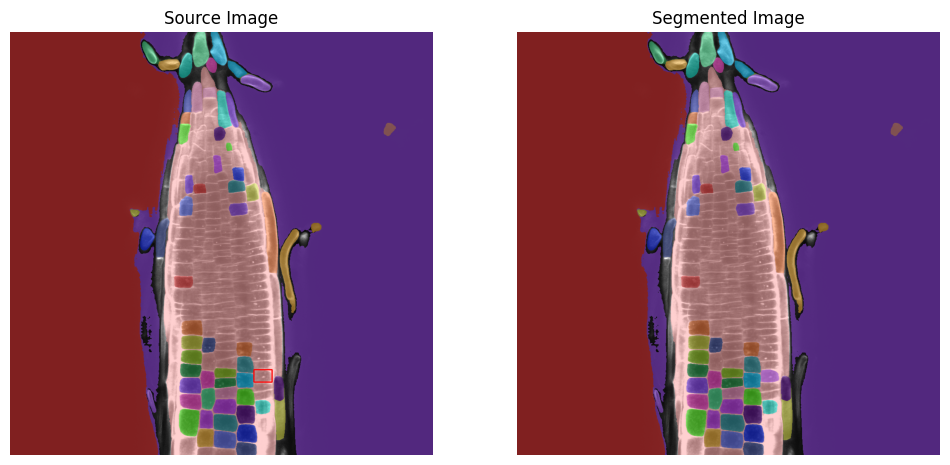

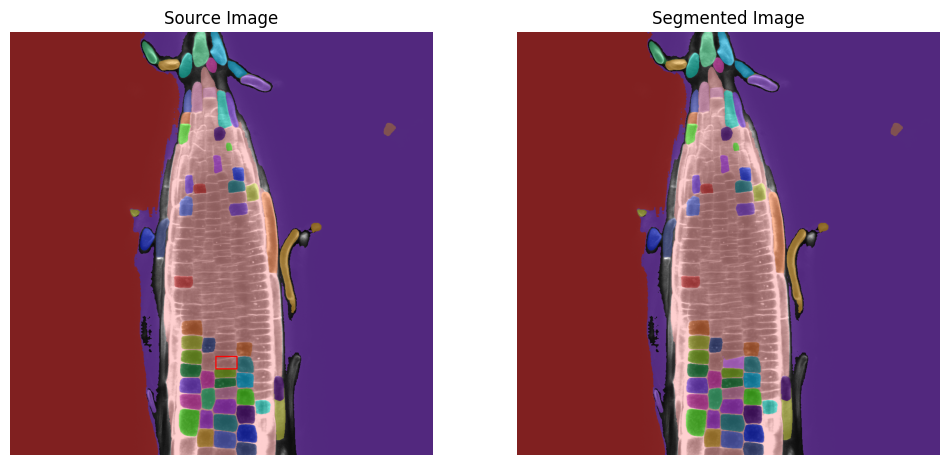

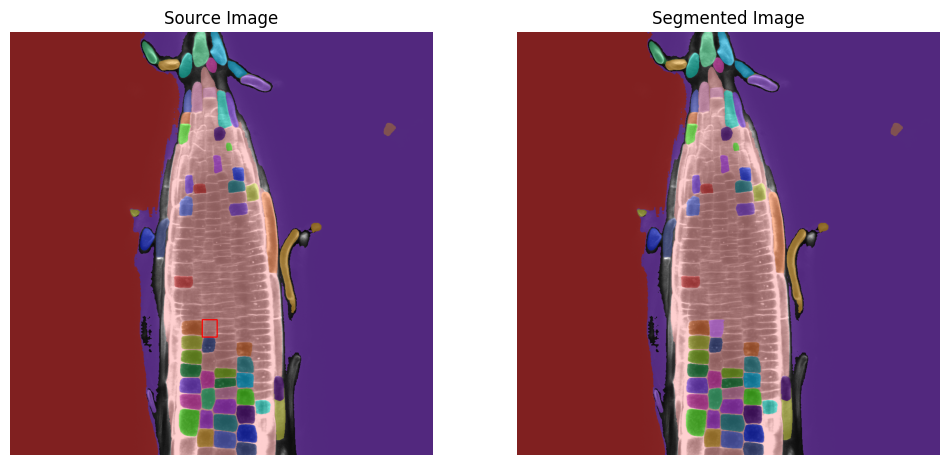

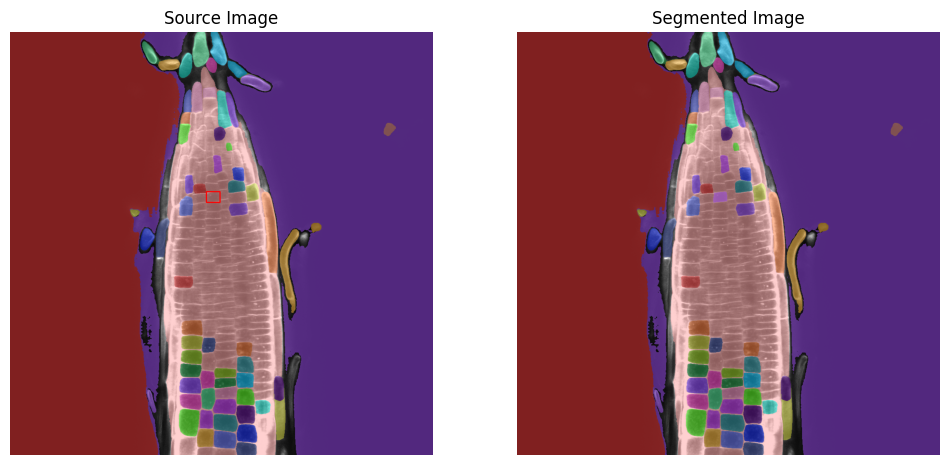

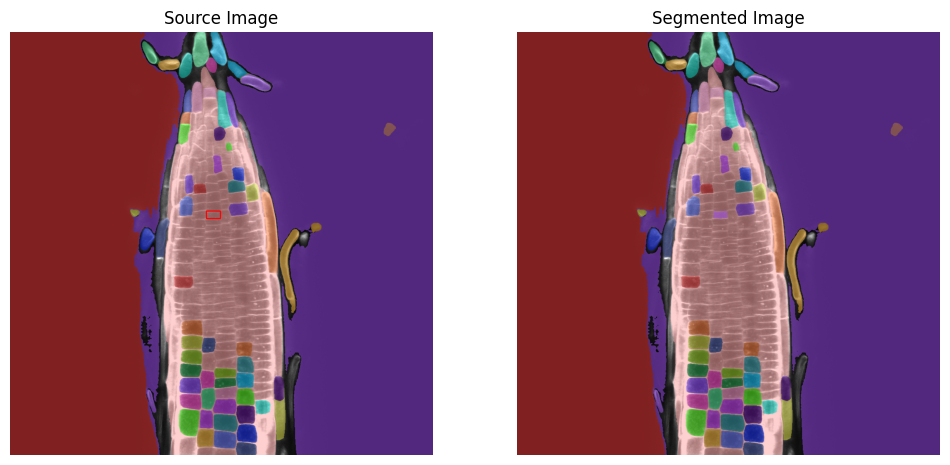

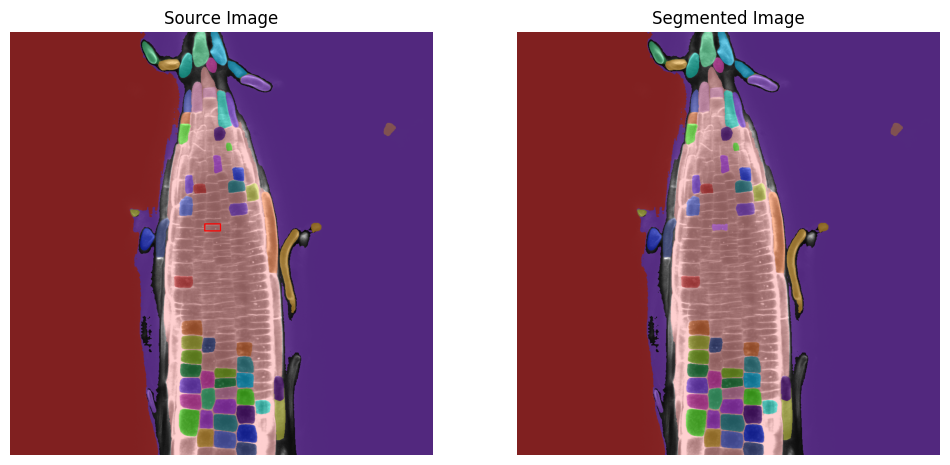

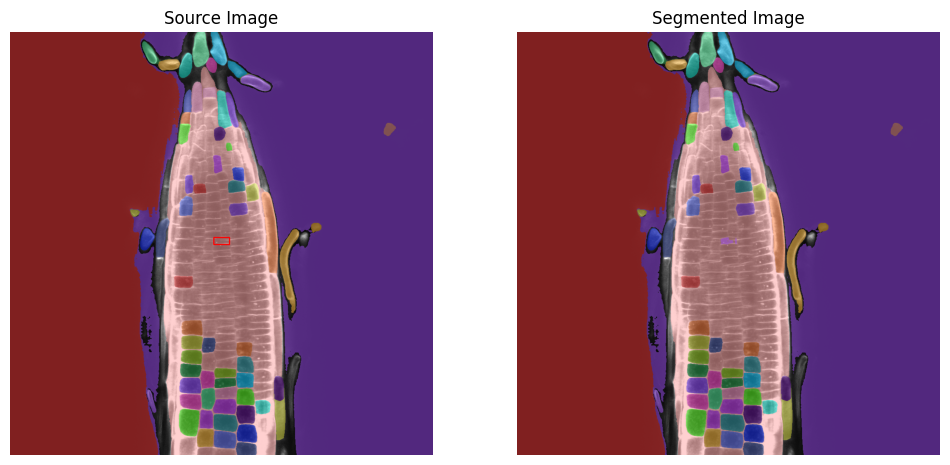

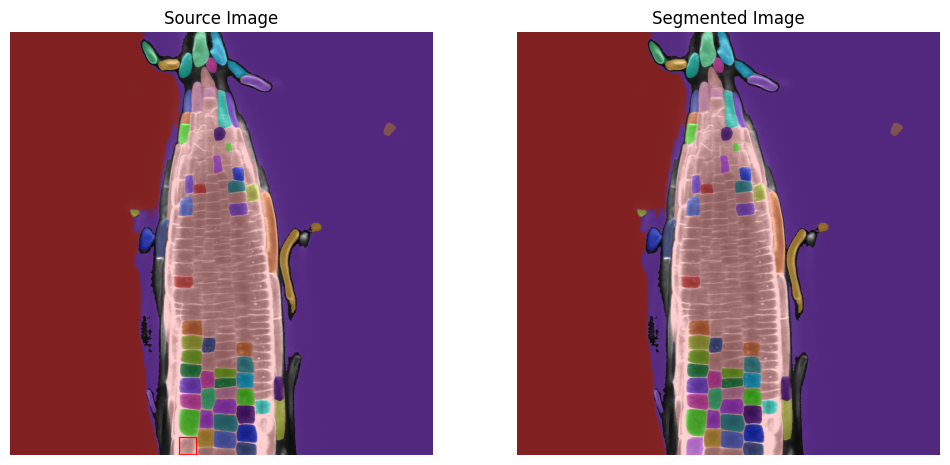

In [47]:
# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 68, 'y': 247, 'width': 555, 'height': 678, 'label': ''}

for i in range(len(widget.bboxes)):
    # Use default_box if no bboxes are drawn
    box = widget.bboxes[i] if widget.bboxes else default_box
    box = np.array([
        box['x'],
        box['y'],
        box['x'] + box['width'],
        box['y'] + box['height']
    ])
    
    # Set the image for the mask predictor
    mask_predictor.set_image(annotated2_image)
    
    # Predict the mask using the box as a prompt
    mask_prompt, scores, logits = mask_predictor.predict(
        box=box,
        multimask_output=False
    )
    
    # Append the mask to the list of masks
    prompt_masks.append(mask_prompt[0])
    
    # Initialize box and mask annotators with color lookup set to INDEX
    box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
    mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
    
    # Create detections from masks
    detections = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=mask_prompt),
        mask=mask_prompt
    )

    # Annotate images
    source_image = box_annotator.annotate(scene=annotated2_image.copy(), detections=detections)
    segmented_image = mask_annotator.annotate(scene=annotated2_image.copy(), detections=detections)

    # Plot images
    sv.plot_images_grid(
        images=[source_image, segmented_image],
        grid_size=(1, 2),
        titles=['Source Image', 'Segmented Image']
    )


In [48]:
# Run this cell to save the detected cell masks as a pickle
total = selected_masks + prompt_masks
with open(f"/projects/intro2gds/Chirag_2024/mask_sam_filtered/masks5.pkl", 'wb') as file:
    pickle.dump(total, file)

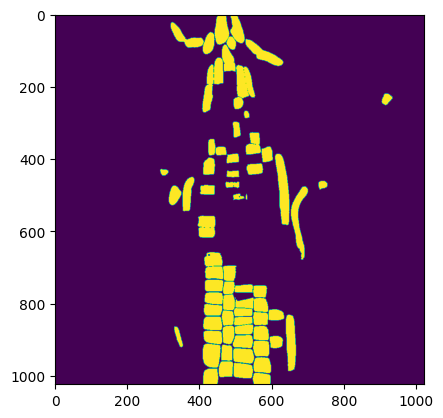

In [49]:
# Assuming you have a list of object masks (masks) and an image size (image_height, image_width)

# Initialize an empty mask with the same dimensions as your image
total = selected_masks + prompt_masks
empty_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Iterate through the 10 individual object masks and combine them
i = 0
for object_mask in total:

    empty_mask = np.logical_or(empty_mask, object_mask)

plt.imshow(empty_mask)

In [50]:
# extra
# Check the type of each element in 'total'
for idx, item in enumerate(total):
    if isinstance(item, bool):
        print(f"Element at index {idx} is a boolean: {item}")


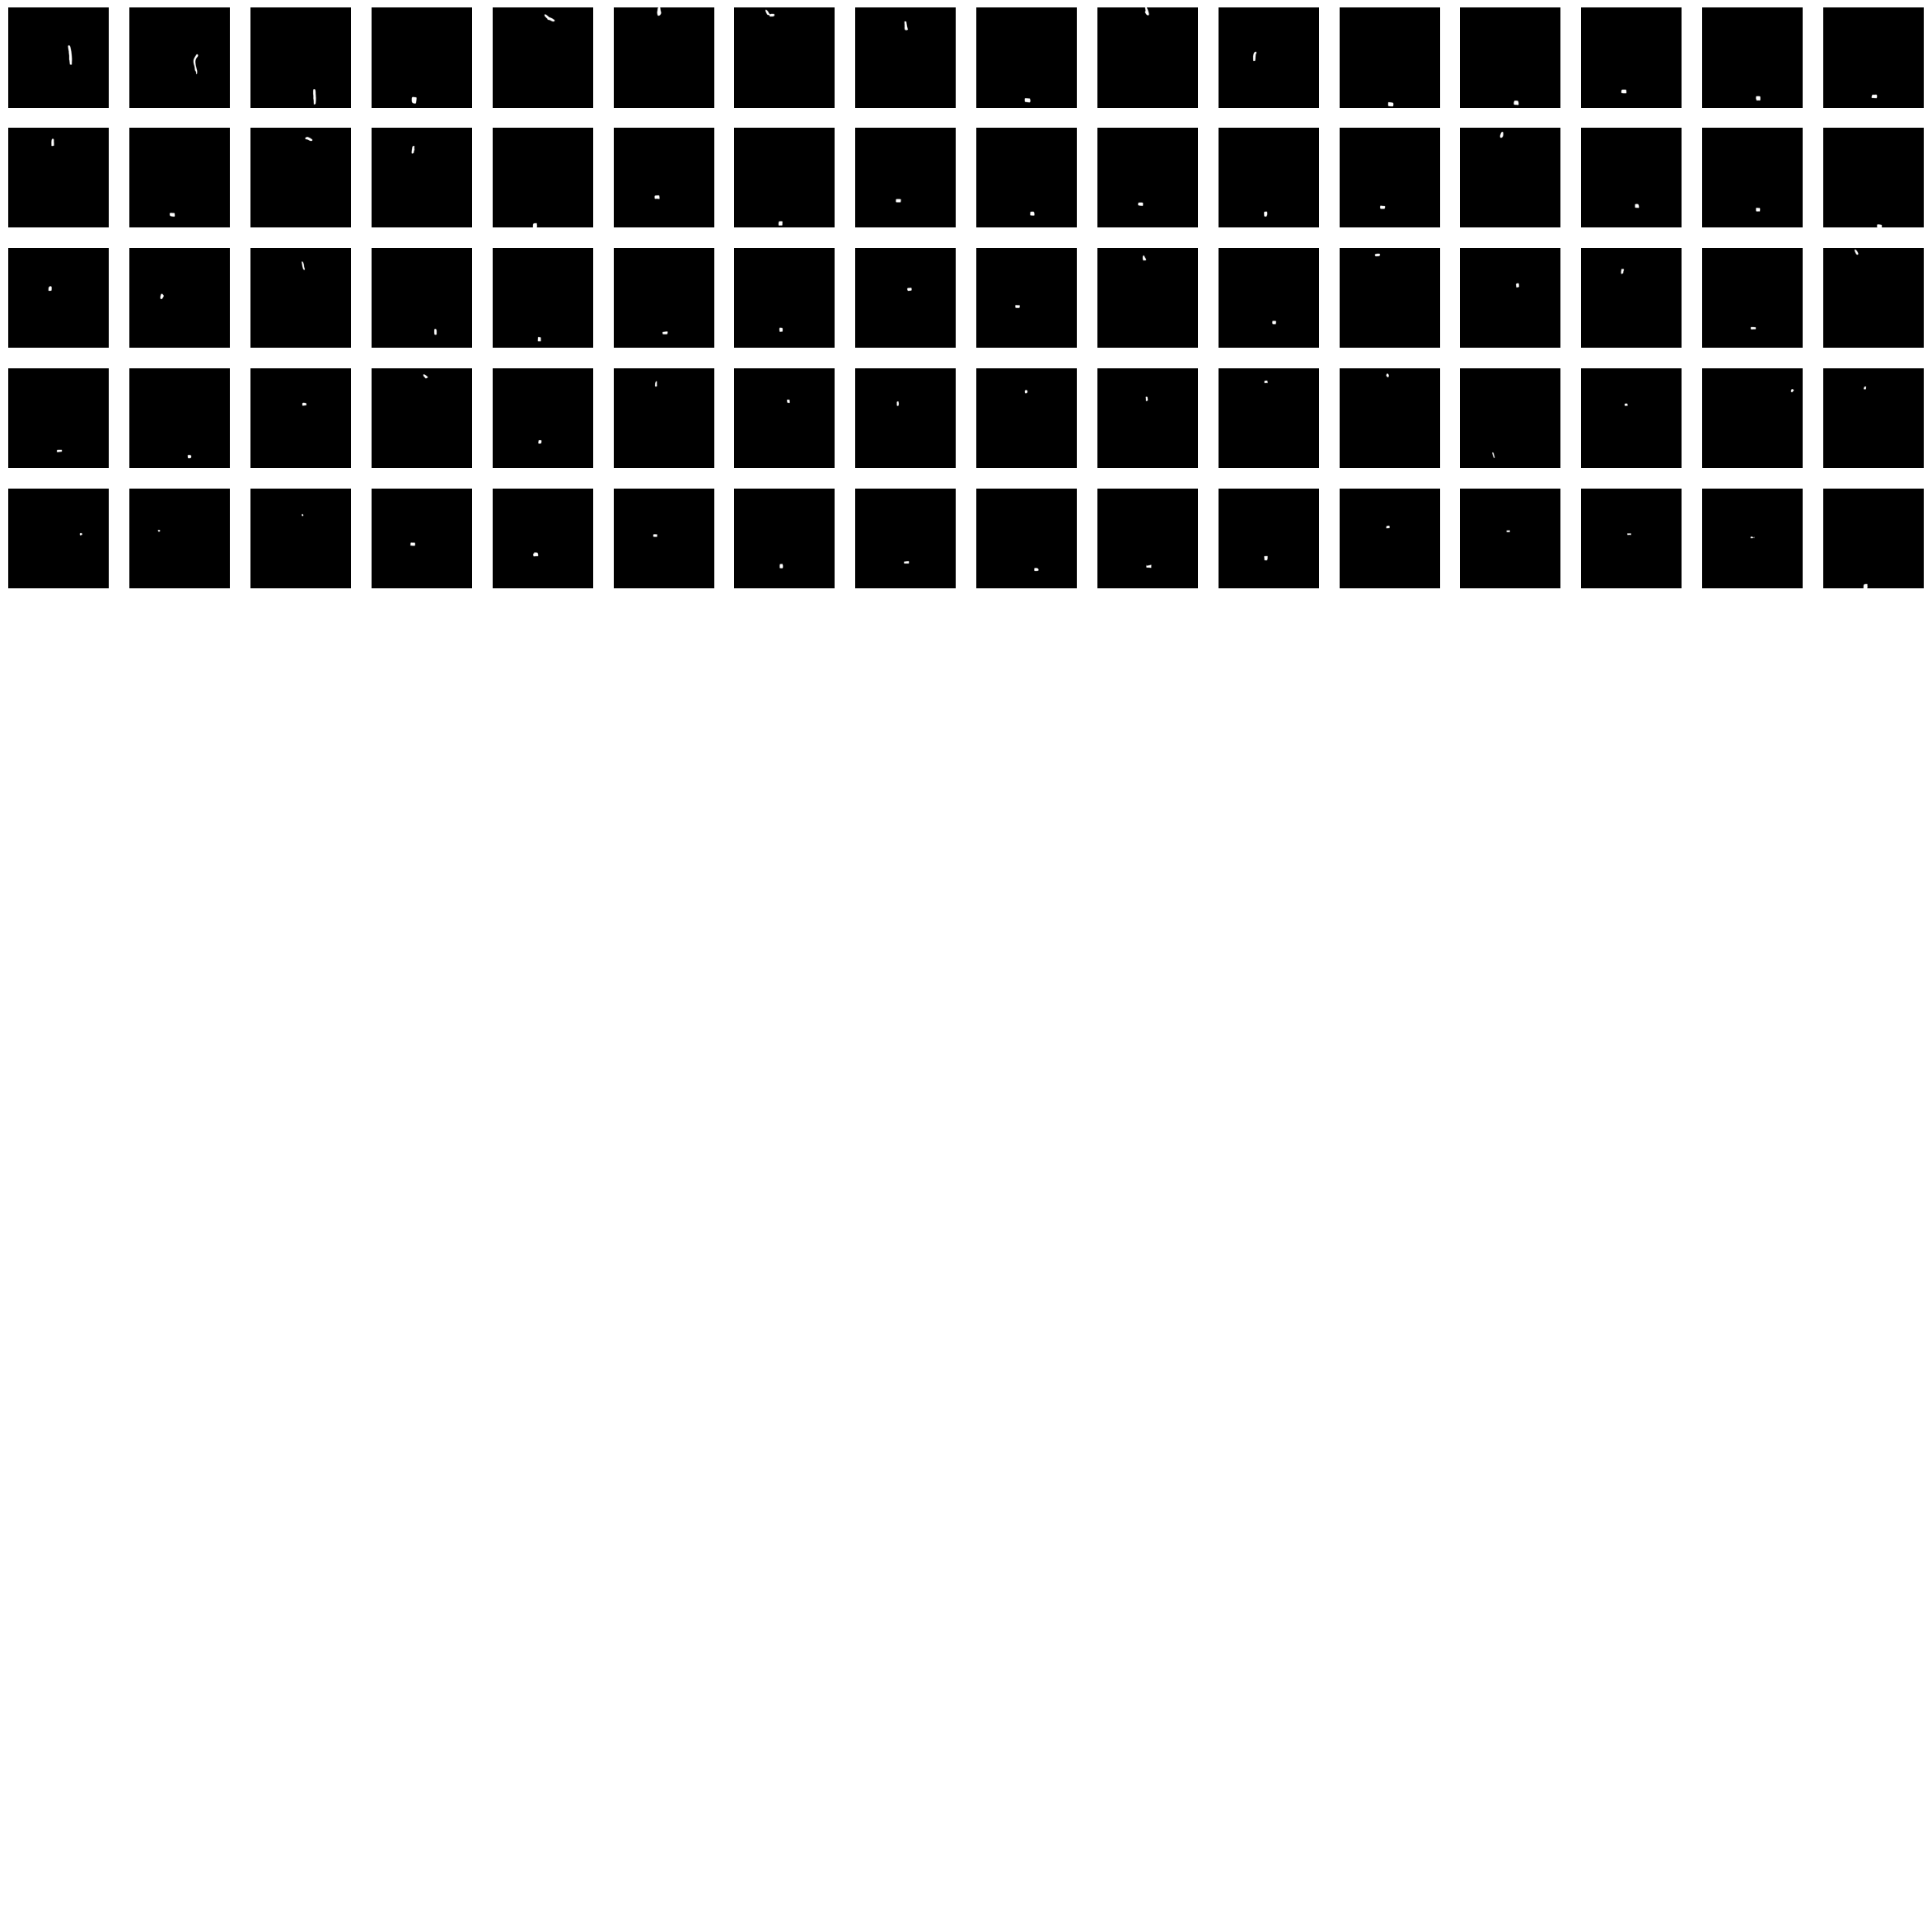

In [51]:
# Display the masks as a grid
import supervision as sv
sv.plot_images_grid(
    images=total,
    # grid_size=(16, int(len(masks) / 16)),
    grid_size= (16, 16),
    size=(30, 30)
)